## Lưu phạm vi của sentinel lên các tỉnh trong phạm vi đó vào file json

In [9]:
import pandas as pd
import numpy as np
import json


'''
    Xử lý khu vực ảnh đang có đặc điểm đó có tỉnh nào đang ở bên trong
'''

sen_2_local = pd.read_csv('./bounding_box/sentinel-2_2019-2024_bboxs.csv')
sen_1_local = pd.read_csv('./bounding_box/sentinel-1_2019-2024_bboxs.csv')
provine_local = pd.read_csv('./bounding_box/mekong_provinces_bbox.csv')



def rect_touch_or_overlap(r1, r2):
    # r = (xmin, ymin, xmax, ymax) ; đảm bảo xmin<=xmax, ymin<=ymax
    x1min, x1max, y1min, y1max = r1
    x2min, x2max, y2min, y2max = r2

    dx = min(x1max, x2max) - max(x1min, x2min)
    dy = min(y1max, y2max) - max(y1min, y2min)

    if dx > 0 and dy >0:
        return True
    return False


process_sen_2 = {}
process_sen_1 = {}
process_province = {}

for _,item in provine_local.iterrows():
    process_province[item.get('province')] = (item.minx, item.maxx, item.miny, item.maxy)

for _,item in sen_2_local.iterrows():
    process_sen_2[item.product_id] = (item.minx, item.maxx, item.miny, item.maxy)

for _,item in sen_1_local.iterrows():
    process_sen_1[item.image_id] = (item.minx, item.maxx, item.miny, item.maxy)

def process(sentinel: dict, province: dict, file_path):
    res = {}
    for key, (minx, maxx, miny, maxy) in sentinel.items():
        tmp = []
        r1 = (minx, maxx, miny, maxy)
        for key1, (minx1, maxx1, miny1, maxy1) in province.items():
            r2 = (minx1, maxx1, miny1, maxy1)
            if rect_touch_or_overlap(r1, r2):
                tmp.append(key1)
        res[key] = tmp
    
    try:
        with open(file_path, 'w', encoding='utf-8') as f:
            json.dump(res, f, indent=4, ensure_ascii=False)
        print(f'Save data success to {file_path}')
    except Exception as e:
        print(f'Error save data: {e}')

process(process_sen_1, process_province, './province_in_sentinel_1.json')
process(process_sen_2, process_province, './province_in_sentinel_2.json')




Save data success to ./province_in_sentinel_1.json
Save data success to ./province_in_sentinel_2.json


## Lưu metadata theo từng năm và từng sentinel

In [10]:
import os
import json

'''
    Lưu các metadata vào 1 file json duy nhất

'''


directory_path_sen_2_2019 = "./dataset/sentinel-2/dbscl-sentinel-2-2019"
directory_path_sen_2_2020 = "./dataset/sentinel-2/dbscl-sentinel-2-2020"
directory_path_sen_1_2023 = "./sentinel-1-more-features/sentinel-1-more-features/dbscl-sentinel-1-2023"
directory_path_sen_1_2024 = "./sentinel-1-more-features/sentinel-1-more-features/dbscl-sentinel-1-2024"

output_path_sen_2_2019 = "./sentinel_2_2019.json"
output_path_sen_2_2020 = './sentinel_2_2020.json'
output_path_sen_1_2023 = './sentinel_1_2023.json'
output_path_sen_1_2024 = './sentinel_1_2024.json'


# Mở file ghi 1 lần duy nhất
def Save_metadata_in_a_file_json(output_path, directory_path):
    metadata_list = []
    with open(output_path, 'w', encoding='utf-8') as w:
        for dirpath, dirnames, filenames in os.walk(directory_path):
            for filename in filenames:
                if filename.endswith('.json'):
                    file_path = os.path.join(dirpath, filename)
                    try:
                        with open(file_path, 'r', encoding='utf-8') as f:
                            data = json.load(f)
                            metadata_list.append(data)

                            # Ghi mỗi metadata trên một dòng JSON
                            w.write(json.dumps(data, ensure_ascii=False) + '\n')
                    except Exception as e:
                        print(f"⚠️ Error reading {file_path}: {e}")

    print(f"\nTổng số file metadata đọc được: {len(metadata_list)}")
    print(f"Đã lưu tất cả metadata vào: {output_path}")


Save_metadata_in_a_file_json(output_path_sen_2_2019, directory_path_sen_2_2019)
Save_metadata_in_a_file_json(output_path_sen_2_2020, directory_path_sen_2_2020)
Save_metadata_in_a_file_json(output_path_sen_1_2023, directory_path_sen_1_2023)
Save_metadata_in_a_file_json(output_path_sen_1_2024, directory_path_sen_1_2024)


Tổng số file metadata đọc được: 632
Đã lưu tất cả metadata vào: ./sentinel_2_2019.json

Tổng số file metadata đọc được: 527
Đã lưu tất cả metadata vào: ./sentinel_2_2020.json

Tổng số file metadata đọc được: 287
Đã lưu tất cả metadata vào: ./sentinel_1_2023.json

Tổng số file metadata đọc được: 288
Đã lưu tất cả metadata vào: ./sentinel_1_2024.json


## Tương quan các feature của sentinel-1 với lượng mưa

Các feature chọn là: 'VV_mean', 'VH_mean', 'RVI_mean', 'Total_Backscatter_mean', 'Diff_Backscatter_mean', 'VV_VH_ratio_mean', 'DPSVI_mean', 'angle_mean', 'province', 'time'



In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

def load_sentinel1(file_path):
    records = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                d = json.loads(line)
                stats = d.get("features_statistics", {})
                stats["product_id"] = d.get("system:index")
                stats["time"] = d.get("system:time_start")
                records.append(stats)
            except:
                continue
    return pd.DataFrame(records)


#  Nối metadata của 2023 với 2024
s1_2023 = load_sentinel1('./sentinel_1_2023.json')
s1_2024 = load_sentinel1('./sentinel_1_2024.json')
s1_all = pd.concat([s1_2023, s1_2024], ignore_index=True)

'''
    Nối dữ liệu metadata của sentinel-1 với từng tỉnh thuộc vùng sentinel
'''

with open('./province_in_sentinel_1.json', 'r') as f:
    data = json.load(f)

s1_all['province'] = s1_all.apply(
    lambda r: data.get(r['product_id'], []),  # tránh KeyError
    axis=1
)

s1_expanded = s1_all.explode('province')

s1_expanded = s1_expanded[['VV_mean', 'VH_mean', 'RVI_mean', 'Total_Backscatter_mean', 'Diff_Backscatter_mean', 'VV_VH_ratio_mean', 'DPSVI_mean', 'angle_mean', 'province', 'time']].dropna()


## Gộp Lượng mưa trung bình 3 ngày trước + 3 ngày sau + ngày hiện tại của metadata sentinel 1

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

rain = pd.read_csv('./chirps_mekong_delta_2019_2024_full.csv')
rain['date'] = pd.to_datetime(rain['date'])

# Kiểm tra dữ liệu
# print(rain.head())
# print(rain['province'].unique())



s1_expanded['date'] = pd.to_datetime(s1_expanded['time'], unit='ms') 

# Gộp trung bình mưa trong 4 ngày quanh thời điểm radar
def rainfall_window(df, province, date, window=4):
    subset = df[(df['province'] == province) &
                (df['date'].between(date - pd.Timedelta(days=window),
                                    date + pd.Timedelta(days=window)))]
    return subset['precipitation'].mean() if not subset.empty else None

s1_expanded['rainfall_3_days'] = s1_expanded.apply(
    lambda r: rainfall_window(rain, r['province'], r['date'],3),
    axis=1
)








# Lưu data vào file final_process_sentinel_1.csv

In [ ]:
s1_expanded.to_csv('./final_process_sentinel_1.csv', index=False, encoding='utf-8')
    

## Chỉ số tương quan của các feature với lượng mưa

✅ Ma trận tương quan có kích thước: (10, 10)
                         VV_mean   VH_mean  RVI_mean  Total_Backscatter_mean  \
VV_mean                 1.000000  0.889454 -0.039141                0.966933   
VH_mean                 0.889454  1.000000 -0.062729                0.976597   
RVI_mean               -0.039141 -0.062729  1.000000               -0.053424   
Total_Backscatter_mean  0.966933  0.976597 -0.053424                1.000000   
Diff_Backscatter_mean  -0.100404 -0.544021  0.064700               -0.350826   

                        Diff_Backscatter_mean  VV_VH_ratio_mean  DPSVI_mean  \
VV_mean                             -0.100404         -0.573995    0.966933   
VH_mean                             -0.544021         -0.324590    0.976597   
RVI_mean                             0.064700         -0.022289   -0.053424   
Total_Backscatter_mean              -0.350826         -0.451250    1.000000   
Diff_Backscatter_mean                1.000000         -0.347187   -0.350826   


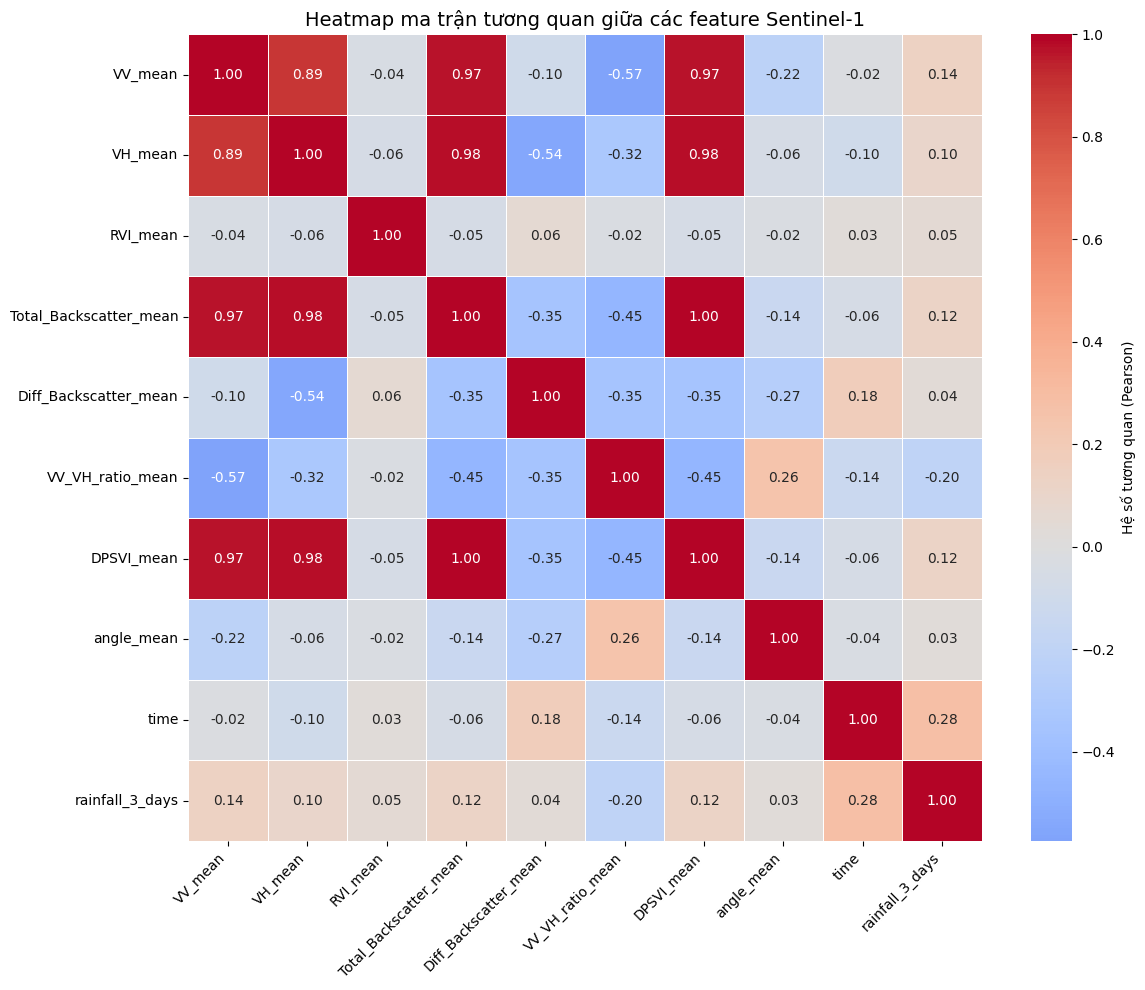

In [5]:
# ============================================
# 🔍 EDA: Heatmap ma trận tương quan giữa các feature (bao gồm lượng mưa)
# ============================================

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 👉 Giữ lại các cột dạng số
num_df = s1_expanded.select_dtypes(include=[np.number]).dropna(axis=1, how='all')

# 1️⃣ Tính ma trận tương quan Pearson giữa tất cả các feature
corr_matrix = num_df.corr(method='pearson')

# 2️⃣ In nhanh kích thước và 5 hàng đầu tiên
print(f"✅ Ma trận tương quan có kích thước: {corr_matrix.shape}")
print(corr_matrix.head())

# 3️⃣ Vẽ heatmap có giá trị tương quan
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',           # Thang màu xanh–đỏ
    center=0,                  # Màu trung tính cho giá trị 0
    annot=True,                # 🔹 Hiển thị giá trị tương quan
    fmt=".2f",                 # 2 chữ số thập phân
    linewidths=0.5,            # Đường viền mảnh giữa các ô
    cbar_kws={'label': 'Hệ số tương quan (Pearson)'}  # Nhãn cho thanh màu
)

plt.title("Heatmap ma trận tương quan giữa các feature Sentinel-1", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Tìm tương quan các feature của sentinel-2 với lượng mưa

Các feature chọn: "CLOUDY_PIXEL_PERCENTAGE",
    "THIN_CIRRUS_PERCENTAGE",
    "VEGETATION_PERCENTAGE",
    "MEAN_SOLAR_ZENITH_ANGLE",
    "WATER_PERCENTAGE",
    "SNOW_ICE_PERCENTAGE",'product_id', 'time'

In [6]:
'''
    Xử lý sentinel-2

    "GRANULE_MEAN_AOT",
    "GRANULE_MEAN_WV",
    "OZONE_VALUE",
    "CLOUDY_PIXEL_PERCENTAGE",
    "THIN_CIRRUS_PERCENTAGE",
    "VEGETATION_PERCENTAGE",
    "MEAN_SOLAR_ZENITH_ANGLE",
    "WATER_PERCENTAGE",
    "SNOW_ICE_PERCENTAGE",    
    
'''
import  pandas as pd
import json



def load_sentinel2(file_path):
    records = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            # print(line)
            try:
                d = json.loads(line)
                stats = {}
                # stats["GRANULE_MEAN_AOT"] = d.get("GRANULE_MEAN_AOT")
                # stats["GRANULE_MEAN_WV"] = d.get("GRANULE_MEAN_WV")
                # stats["OZONE_VALUE"] = d.get("OZONE_VALUE")
                stats["CLOUDY_PIXEL_PERCENTAGE"] = d.get("CLOUDY_PIXEL_PERCENTAGE")
                stats["THIN_CIRRUS_PERCENTAGE"] = d.get("THIN_CIRRUS_PERCENTAGE")
                stats["VEGETATION_PERCENTAGE"] = d.get("VEGETATION_PERCENTAGE")
                stats["MEAN_SOLAR_ZENITH_ANGLE"] = d.get("MEAN_SOLAR_ZENITH_ANGLE")
                stats["WATER_PERCENTAGE"] = d.get("WATER_PERCENTAGE")
                stats["SNOW_ICE_PERCENTAGE"] = d.get("SNOW_ICE_PERCENTAGE")
                stats["product_id"] = d.get("PRODUCT_ID")
                stats["time"] = d.get("GENERATION_TIME")
                records.append(stats)
            except:
                continue
    return pd.DataFrame(records)



#  Nối metadata của 2023 với 2024
s2_2019 = load_sentinel2('./sentinel_2_2019.json')
s2_2020 = load_sentinel2('./sentinel_2_2020.json')
s2_all = pd.concat([s2_2019, s2_2020], ignore_index=True)

s2_all = s2_all[["CLOUDY_PIXEL_PERCENTAGE",
    "THIN_CIRRUS_PERCENTAGE",
    "VEGETATION_PERCENTAGE",
    "MEAN_SOLAR_ZENITH_ANGLE",
    "WATER_PERCENTAGE",
    "SNOW_ICE_PERCENTAGE",'product_id', 'time']].dropna()

with open('./province_in_sentinel_2.json', 'r') as f:
    data = json.load(f)

s2_all['province'] = s2_all.apply(
    lambda r: data.get(r['product_id'], []),  # tránh KeyError
    axis=1
)

s2_expanded = s2_all.explode('province')


rain = pd.read_csv('./chirps_mekong_delta_2019_2024_full.csv')
rain['date'] = pd.to_datetime(rain['date'])


s2_expanded['date'] = pd.to_datetime(s2_expanded['time'], unit='ms') 

# Gộp trung bình mưa trong 4 ngày quanh thời điểm radar
def rainfall_window(df, province, date, window=4):
    subset = df[(df['province'] == province) &
                (df['date'].between(date - pd.Timedelta(days=window),
                                    date + pd.Timedelta(days=window)))]
    return subset['precipitation'].mean() if not subset.empty else None

s2_expanded['rainfall_3_days'] = s2_expanded.apply(
    lambda r: rainfall_window(rain, r['province'], r['date'],3),
    axis=1
)


In [ ]:
## Lưu data vào file csv

In [18]:
s2_expanded.to_csv('./final_process_sentinel_2.csv', index=False, encoding='utf-8')

✅ Ma trận tương quan có kích thước: (8, 8)
                         CLOUDY_PIXEL_PERCENTAGE  THIN_CIRRUS_PERCENTAGE  \
CLOUDY_PIXEL_PERCENTAGE                 1.000000                0.471733   
THIN_CIRRUS_PERCENTAGE                  0.471733                1.000000   
VEGETATION_PERCENTAGE                  -0.415388               -0.270008   
MEAN_SOLAR_ZENITH_ANGLE                -0.351761                0.023548   
WATER_PERCENTAGE                       -0.170162                0.167260   

                         VEGETATION_PERCENTAGE  MEAN_SOLAR_ZENITH_ANGLE  \
CLOUDY_PIXEL_PERCENTAGE              -0.415388                -0.351761   
THIN_CIRRUS_PERCENTAGE               -0.270008                 0.023548   
VEGETATION_PERCENTAGE                 1.000000                 0.225453   
MEAN_SOLAR_ZENITH_ANGLE               0.225453                 1.000000   
WATER_PERCENTAGE                     -0.683330                 0.098536   

                         WATER_PERCENTAGE  SNOW_I

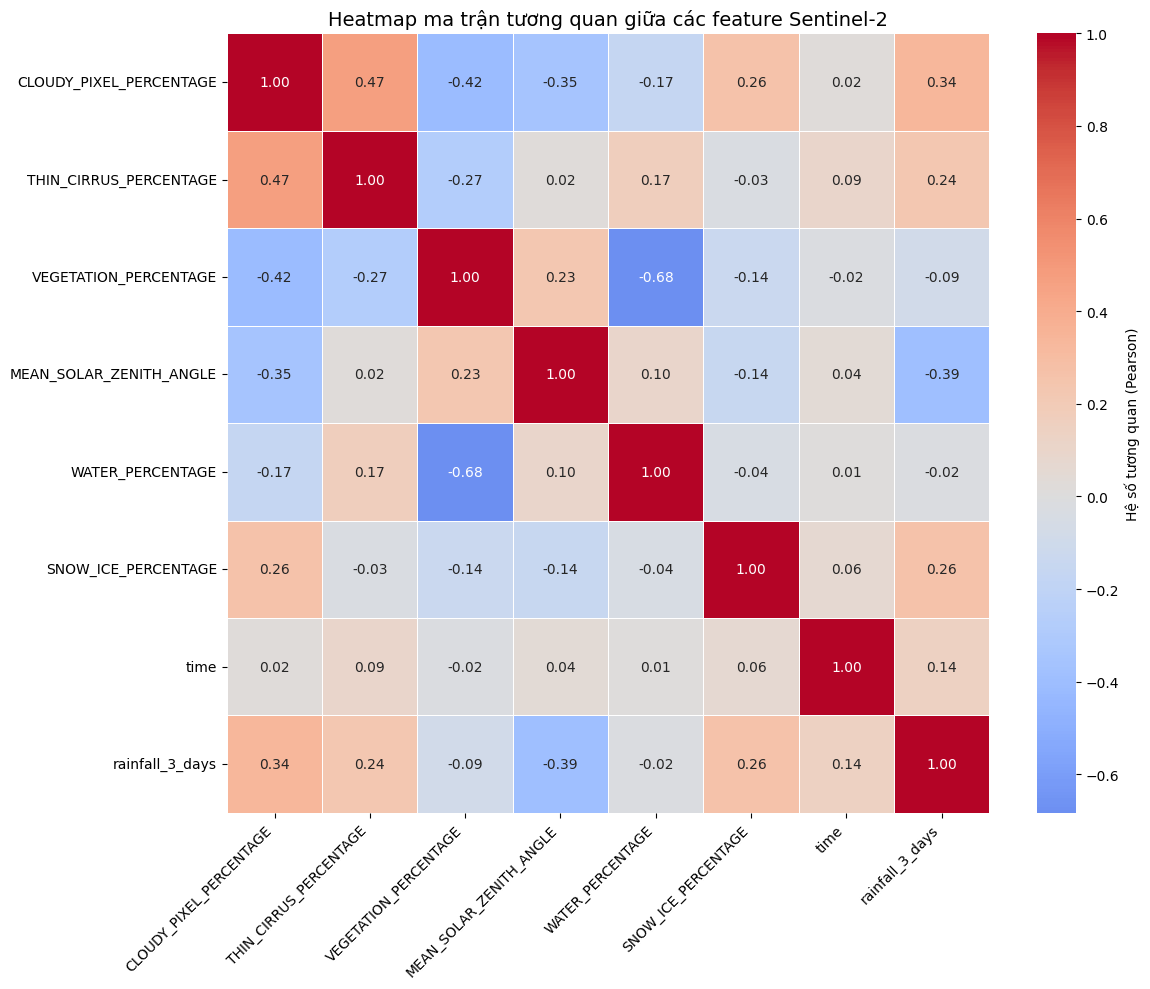

In [7]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 👉 Giữ lại các cột dạng số
num_df = s2_expanded.select_dtypes(include=[np.number]).dropna(axis=1, how='all')

# 1️⃣ Tính ma trận tương quan
corr_matrix = num_df.corr(method='pearson')

# 2️⃣ Hiển thị kích thước và top vài cột
print(f"✅ Ma trận tương quan có kích thước: {corr_matrix.shape}")
print(corr_matrix.head())

# 3️⃣ Tạo heatmap có giá trị tương quan
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',         # thang màu đỏ/xanh
    center=0,                # 0 nằm giữa
    annot=True,              # 🔹 Hiển thị giá trị tương quan
    fmt=".2f",               # hiển thị 2 chữ số thập phân
    linewidths=0.5,          # đường viền mảnh giữa các ô
    cbar_kws={'label': 'Hệ số tương quan (Pearson)'}  # thêm chú thích cho thanh màu
)

plt.title("Heatmap ma trận tương quan giữa các feature Sentinel-2", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
